In [1]:
# ========================================
# AfyaMetrix Risk Scoring Module
# Notebook: 03_risk_scoring.ipynb
# ========================================
#
# The Risk Score (0-100) combines multiple factors:
#
# Factor 1: Case Growth Rate (35%) 
#   → How fast are cases INCREASING?
#
# Factor 2: Anomaly Confidence (25%)
#   → Has our AI flagged this as unusual?
#
# Factor 3: Disease Severity Weight (20%)
#   → Is this Ebola or a common cold? Not all diseases equal.
#
# Factor 4: Healthcare Access Inverse (10%)
#   → Low access regions are MORE at risk from the same outbreak
#
# Factor 5: Population Density Factor (10%)
#   → More people = faster spread potential

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports successful")
print("⚖️  Building AfyaMetrix Risk Scoring Engine...")

✅ Imports successful
⚖️  Building AfyaMetrix Risk Scoring Engine...


In [2]:
# ========================================
# LOAD DATA + DEFINE DISEASE SEVERITY
# ========================================

df = pd.read_csv(
    r"C:\Users\hassa\afyametrix\data\processed\africa_health_anomalies.csv"
)
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Loaded {len(df):,} records")

# ----------------------------------------
# DISEASE SEVERITY WEIGHTS
# ----------------------------------------
# Not all diseases carry the same risk.
# A spike in Mpox or Cholera demands faster response
# than a spike in common respiratory infections.
#
# Scale: 0.0 to 1.0
# Based on: case fatality rate + transmission speed + treatment availability

DISEASE_SEVERITY = {
    "Mpox":                   0.85,  # high — explosive spread, limited treatment
    "Cholera":                0.90,  # very high — kills within hours if untreated
    "Meningitis":             0.95,  # very high — highest fatality if untreated
    "Malaria":                0.70,  # high — #1 killer in Africa but treatable
    "Tuberculosis":           0.75,  # high — long treatment, drug resistance risk
    "Typhoid":                0.60,  # medium-high — treatable but spreads fast
    "Dengue":                 0.65,  # medium-high — no specific treatment
    "Diarrheal_Disease":      0.50,  # medium — dangerous for children/elderly
    "Respiratory_Infections": 0.45,  # medium — broad category, mostly manageable
    "Malnutrition":           0.55,  # medium — chronic but compounding risk
}

print("\n📊 Disease Severity Weights:")
for disease, weight in sorted(DISEASE_SEVERITY.items(), 
                               key=lambda x: x[1], reverse=True):
    bar = "█" * int(weight * 20)
    print(f"  {disease:<25} {bar} {weight}")

✅ Loaded 497,080 records

📊 Disease Severity Weights:
  Meningitis                ███████████████████ 0.95
  Cholera                   ██████████████████ 0.9
  Mpox                      █████████████████ 0.85
  Tuberculosis              ███████████████ 0.75
  Malaria                   ██████████████ 0.7
  Dengue                    █████████████ 0.65
  Typhoid                   ████████████ 0.6
  Malnutrition              ███████████ 0.55
  Diarrheal_Disease         ██████████ 0.5
  Respiratory_Infections    █████████ 0.45


In [3]:
# ========================================
# FACTOR 1: CASE GROWTH RATE
# ========================================
#
# We compare the last 7 days average to the previous 7 days average.
# This is called a "week-over-week" growth rate.
#
# Example:
#   Last 7 days avg: 300 cases/day
#   Previous 7 days avg: 100 cases/day
#   Growth rate: (300-100)/100 = 200% increase → very dangerous
#
# We cap at 500% to prevent extreme outliers from dominating the score.

print("⚙️  Calculating growth rates...")

def calculate_growth_rate(df):
    groups = df.groupby(['country', 'region', 'disease'])
    results = []
    
    for name, group in groups:
        group = group.copy().sort_values('date')
        
        # 7-day rolling average
        rolling_7d = group['cases'].rolling(window=7, min_periods=3).mean()
        
        # Previous 7-day period (shift by 7 days)
        rolling_7d_prev = rolling_7d.shift(7)
        
        # Week-over-week growth rate
        growth = np.where(
            rolling_7d_prev > 0,
            (rolling_7d - rolling_7d_prev) / rolling_7d_prev * 100,
            0  # if no previous data, growth = 0
        )
        
        # Cap at -100% (can't have less than 0 cases) 
        # and +500% (extreme cap to prevent score distortion)
        group['growth_rate_pct'] = np.clip(growth, -100, 500).round(2)
        
        # 7-day average for reference
        group['avg_cases_7d'] = rolling_7d.round(1)
        
        results.append(group)
    
    return pd.concat(results).sort_values(
        ['country', 'region', 'disease', 'date']
    ).reset_index(drop=True)

df = calculate_growth_rate(df)

print(f"✅ Growth rates calculated")
print(f"\n📈 Growth rate statistics:")
print(f"   Max growth:  {df['growth_rate_pct'].max():.1f}%")
print(f"   Mean growth: {df['growth_rate_pct'].mean():.1f}%")
print(f"   Days with >100% growth: {(df['growth_rate_pct'] > 100).sum():,}")

⚙️  Calculating growth rates...
✅ Growth rates calculated

📈 Growth rate statistics:
   Max growth:  500.0%
   Mean growth: 9.8%
   Days with >100% growth: 29,051


In [4]:
# ========================================
# THE RISK SCORE FORMULA
# ========================================

def calculate_risk_scores(df, disease_severity=DISEASE_SEVERITY):
    """
    Calculates a 0-100 risk score for every record.
    
    The formula combines 5 factors with different weights.
    Each factor is first normalized to 0-1, then weighted,
    then multiplied by 100 to get the final 0-100 score.
    """
    
    print("⚙️  Calculating risk scores...")
    
    df = df.copy()
    
    # ----------------------------------------
    # FACTOR 1: Growth Rate Score (weight: 35%)
    # ----------------------------------------
    # Normalize growth rate from -100 to +500 range → 0 to 1
    # Growth of 0% → score of ~0.17 (neutral, not zero)
    # Growth of 500% → score of 1.0 (maximum danger)
    # Declining cases → score approaches 0
    
    df['f1_growth'] = np.clip(
        (df['growth_rate_pct'] + 100) / 600,  # shift and scale to 0-1
        0, 1
    )
    
    # ----------------------------------------
    # FACTOR 2: Anomaly Confidence Score (weight: 25%)
    # ----------------------------------------
    # Our anomaly confidence is already 0-100, just scale to 0-1
    
    df['f2_anomaly'] = np.clip(df['anomaly_confidence'] / 100, 0, 1)
    
    # ----------------------------------------
    # FACTOR 3: Disease Severity (weight: 20%)
    # ----------------------------------------
    # Map disease name to its severity weight
    # Same weight for every row of the same disease
    
    df['f3_severity'] = df['disease'].map(disease_severity).fillna(0.5)
    
    # ----------------------------------------
    # FACTOR 4: Healthcare Access Inverse (weight: 10%)
    # ----------------------------------------
    # LOW healthcare access = HIGHER risk
    # So we INVERT it: score = 1 - access
    # Kenya (0.65 access) → risk factor = 0.35
    # DRC (0.30 access) → risk factor = 0.70
    
    df['f4_access_risk'] = 1 - df['healthcare_access']
    
    # ----------------------------------------
    # FACTOR 5: Case Volume Factor (weight: 10%)
    # ----------------------------------------
    # Absolute case count matters — 10,000 cases is worse than 10
    # Normalize against the max for this disease
    # This factor is calculated per disease to be fair across diseases
    
    disease_max_cases = df.groupby('disease')['cases'].transform('max')
    df['f5_volume'] = np.clip(df['cases'] / disease_max_cases, 0, 1)
    
    # ----------------------------------------
    # WEIGHTED COMBINATION
    # ----------------------------------------
    # Weights must sum to 1.0
    
    WEIGHTS = {
        'f1_growth':     0.35,   # 35% — growth rate (most important)
        'f2_anomaly':    0.25,   # 25% — AI anomaly detection
        'f3_severity':   0.20,   # 20% — disease danger level
        'f4_access_risk':0.10,   # 10% — healthcare access
        'f5_volume':     0.10,   # 10% — case volume
    }
    
    # Calculate weighted sum
    df['risk_score_raw'] = (
        df['f1_growth']      * WEIGHTS['f1_growth'] +
        df['f2_anomaly']     * WEIGHTS['f2_anomaly'] +
        df['f3_severity']    * WEIGHTS['f3_severity'] +
        df['f4_access_risk'] * WEIGHTS['f4_access_risk'] +
        df['f5_volume']      * WEIGHTS['f5_volume']
    )
    
    # Scale to 0-100 and round to 1 decimal place
    df['risk_score'] = (df['risk_score_raw'] * 100).round(1)
    
    # ----------------------------------------
    # RISK TIER CLASSIFICATION
    # ----------------------------------------
    df['risk_tier'] = pd.cut(
        df['risk_score'],
        bins=[0, 30, 55, 75, 100],
        labels=['🟢 Low', '🟡 Medium', '🟠 High', '🔴 Critical'],
        include_lowest=True
    )
    
    # ----------------------------------------
    # EXPLAINABILITY: What drove this score?
    # ----------------------------------------
    # For each record, identify the TOP contributing factor
    # This powers our "Why was this flagged?" feature
    
    factor_contributions = pd.DataFrame({
        'Growth Rate':       df['f1_growth'] * WEIGHTS['f1_growth'],
        'AI Anomaly':        df['f2_anomaly'] * WEIGHTS['f2_anomaly'],
        'Disease Severity':  df['f3_severity'] * WEIGHTS['f3_severity'],
        'Access Risk':       df['f4_access_risk'] * WEIGHTS['f4_access_risk'],
        'Case Volume':       df['f5_volume'] * WEIGHTS['f5_volume'],
    })
    
    df['top_risk_factor'] = factor_contributions.idxmax(axis=1)
    
    print(f"✅ Risk scores calculated")
    print(f"\n📊 Risk Score Distribution:")
    print(df['risk_tier'].value_counts().to_string())
    print(f"\n   Average risk score: {df['risk_score'].mean():.1f}")
    print(f"   Highest risk score: {df['risk_score'].max():.1f}")
    
    return df

df = calculate_risk_scores(df)

⚙️  Calculating risk scores...
✅ Risk scores calculated

📊 Risk Score Distribution:
risk_tier
🟢 Low         301415
🟡 Medium      190680
🟠 High          4956
🔴 Critical        29

   Average risk score: 29.6
   Highest risk score: 80.2


In [5]:
# ========================================
# DAILY REGIONAL RISK SUMMARY
# ========================================
# 
# Instead of showing risk per disease per day (too granular),
# we aggregate to show ONE risk score per region per day.
# This is what the dashboard heatmap will consume.
#
# Aggregation rule: take the MAXIMUM risk score across all diseases
# Because if ONE disease is critical in a region, the region is critical.

print("⚙️  Generating regional risk summary...")

regional_risk = df.groupby(
    ['date', 'country', 'region', 'healthcare_access', 'population']
).agg(
    max_risk_score    = ('risk_score', 'max'),
    avg_risk_score    = ('risk_score', 'mean'),
    total_cases       = ('cases', 'sum'),
    active_alerts     = ('outbreak_alert', 'sum'),
    top_disease       = ('disease', lambda x: x[df.loc[x.index, 'risk_score'].idxmax()]),
    top_risk_factor   = ('top_risk_factor', lambda x: x[df.loc[x.index, 'risk_score'].idxmax()])
).reset_index()

# Rename for clarity
regional_risk = regional_risk.rename(columns={
    'max_risk_score': 'risk_score',
})

# Add risk tier to regional summary
regional_risk['risk_tier'] = pd.cut(
    regional_risk['risk_score'],
    bins=[0, 30, 55, 75, 100],
    labels=['🟢 Low', '🟡 Medium', '🟠 High', '🔴 Critical'],
    include_lowest=True
)

print(f"✅ Regional summary created")
print(f"   Records: {len(regional_risk):,}")
print(f"   (One row per region per day)")

print(f"\n🚨 Most Critical Regions Right Now (Latest Date):")
latest_date = regional_risk['date'].max()
latest = regional_risk[regional_risk['date'] == latest_date].nlargest(10, 'risk_score')

print(latest[['country', 'region', 'risk_score', 'risk_tier', 
              'total_cases', 'active_alerts', 'top_disease']].to_string(index=False))

⚙️  Generating regional risk summary...
✅ Regional summary created
   Records: 49,708
   (One row per region per day)

🚨 Most Critical Regions Right Now (Latest Date):
 country            region  risk_score risk_tier  total_cases  active_alerts top_disease
Ethiopia     Somali Region        70.8    🟠 High        23892              0     Cholera
Ethiopia              Afar        65.4    🟠 High        19570              0     Cholera
 Senegal          Diourbel        54.9  🟡 Medium         2982              2     Cholera
  Zambia Northern Province        53.9  🟡 Medium         3453              2  Meningitis
     DRC         Kisangani        53.6  🟡 Medium        11289              1  Meningitis
     DRC          Kinshasa        51.5  🟡 Medium        27714              1     Typhoid
 Senegal             Thiès        51.3  🟡 Medium         1332              1  Meningitis
 Senegal       Tambacounda        50.7  🟡 Medium         1754              0  Meningitis
  Zambia            Lusaka     

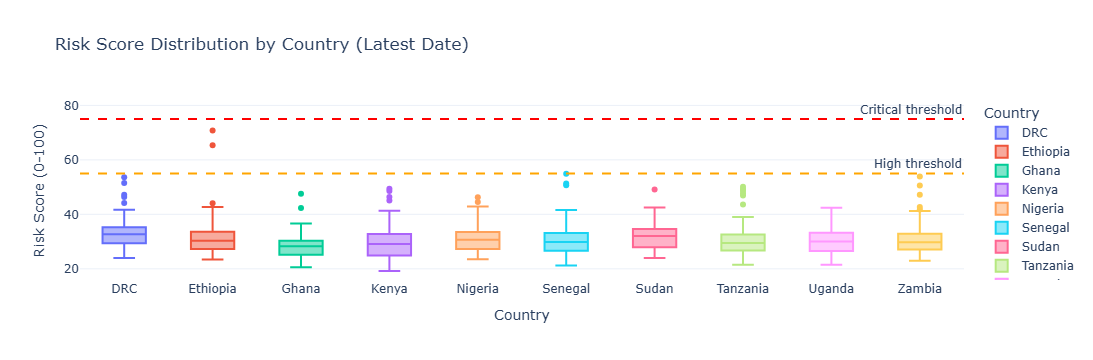

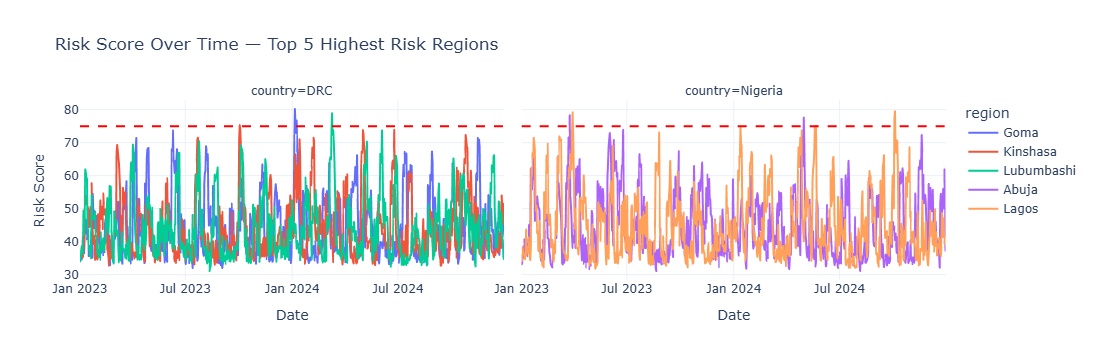

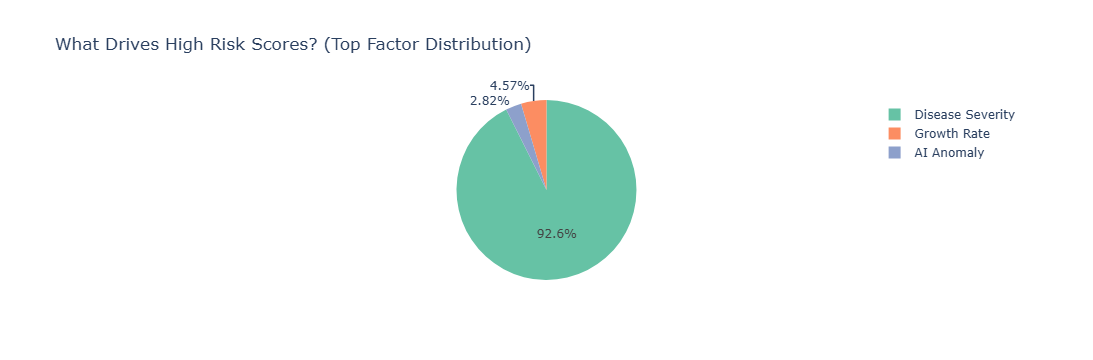

In [6]:
# ========================================
# VISUALIZATIONS
# ========================================

# Chart 1: Risk score distribution by country
fig1 = px.box(
    df[df['date'] == df['date'].max()],
    x='country',
    y='risk_score',
    color='country',
    title='Risk Score Distribution by Country (Latest Date)',
    labels={'risk_score': 'Risk Score (0-100)', 'country': 'Country'},
    template='plotly_white'
)
fig1.add_hline(y=75, line_dash="dash", line_color="red", 
               annotation_text="Critical threshold")
fig1.add_hline(y=55, line_dash="dash", line_color="orange",
               annotation_text="High threshold")
fig1.show()

# Chart 2: Risk score over time for top 5 most at-risk regions
top_regions = (
    regional_risk.groupby(['country', 'region'])['risk_score']
    .mean()
    .nlargest(5)
    .reset_index()
)

top_region_data = regional_risk[
    regional_risk['region'].isin(top_regions['region'])
]

fig2 = px.line(
    top_region_data,
    x='date',
    y='risk_score',
    color='region',
    facet_col='country',
    title='Risk Score Over Time — Top 5 Highest Risk Regions',
    labels={'risk_score': 'Risk Score', 'date': 'Date'},
    template='plotly_white'
)
fig2.add_hline(y=75, line_dash="dash", line_color="red")
fig2.show()

# Chart 3: What factors drive risk the most?
factor_dist = df['top_risk_factor'].value_counts()
fig3 = px.pie(
    values=factor_dist.values,
    names=factor_dist.index,
    title='What Drives High Risk Scores? (Top Factor Distribution)',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig3.show()

In [7]:
# ========================================
# SAVE OUTPUTS
# ========================================

# Save full dataset with risk scores
path1 = r"C:\Users\hassa\afyametrix\data\processed\africa_health_risk_scored.csv"
df.to_csv(path1, index=False)
print(f"✅ Full risk-scored dataset saved")

# Save regional summary (this is what the dashboard uses)
path2 = r"C:\Users\hassa\afyametrix\data\processed\regional_risk_summary.csv"
regional_risk.to_csv(path2, index=False)
print(f"✅ Regional risk summary saved")

print(f"\n📊 Final Dataset Summary:")
print(f"   Full dataset:     {len(df):,} records, {len(df.columns)} columns")
print(f"   Regional summary: {len(regional_risk):,} records")
print(f"\n🎯 Risk Scoring Engine complete.")
print(f"   Every region now has a 0-100 risk score.")
print(f"   Every score has an explanation (top_risk_factor).")
print(f"   Ready for: Forecasting → Resource Allocation → API")

✅ Full risk-scored dataset saved
✅ Regional risk summary saved

📊 Final Dataset Summary:
   Full dataset:     497,080 records, 37 columns
   Regional summary: 49,708 records

🎯 Risk Scoring Engine complete.
   Every region now has a 0-100 risk score.
   Every score has an explanation (top_risk_factor).
   Ready for: Forecasting → Resource Allocation → API
